# «Ставка ЦБ, курс рубля и его волатильность»: сборка результатов

Команда: см. README.

Этот ноутбук последовательно вызывает все скрипты `src/` и показывает
итоговые таблицы и рисунки, которые вошли в презентацию (`slides/`).
Полная инструкция — в `README.md`.

**Главный вывод**: значимость связи «ставка ↔ курс» на полной выборке
целиком объясняется семью кризисными месяцами из 156 (2014-15 и 2022) —
при их нейтрализации дамми-переменными значимость исчезает. См. Т7 и Р4.

In [1]:
import subprocess, sys, time
from pathlib import Path

ROOT = Path.cwd()
scripts = [
    "src/00_download.py",
    "src/01_prepare.py",
    "src/02_descriptive.py",
    "src/03_var.py",
    "src/04_garch.py",
    "src/05_robustness.py",
    "src/06_outofsample.py",
]

t0 = time.time()
for s in scripts:
    print(f"\n=== {s} ===")
    result = subprocess.run([sys.executable, s], cwd=ROOT, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"{s} завершился с ошибкой")
print(f"\nПолный прогон занял {time.time() - t0:.1f} с.")


=== src/00_download.py ===


Скачиваю ключевую ставку: https://www.cbr.ru/hd_base/KeyRate/?UniDbQuery.Posted=True&UniDbQuery.From=01.01.2013&UniDbQuery.To=23.09.2026
Строк: 3264 -> data/raw/keyrate_raw.csv
Скачиваю курс USD/RUB: https://www.cbr.ru/scripts/XML_dynamic.asp?date_req1=01.01.2013&date_req2=23.09.2026&VAL_NM_RQ=R01235
Строк: 3385 -> data/raw/usdrub_raw.csv
Скачиваю Brent (FRED): https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU
Строк: 10266 -> data/raw/brent_raw.csv

Контрольные суммы записаны в data/raw/checksums.txt:
e1e56132781b1477437a7857e56f772e56b77b056e78f92be71b8e4a72f1076f  keyrate_raw.csv
0edc56f497a383258ecc14691028e6612d81ff9c35a83784c6749429541d0f40  usdrub_raw.csv
fc3ab55170885e666085c1bdcb9ecf864826055d6370b305c6f8cb1b3e34edd0  brent_raw.csv

Загрузка завершена за 3.8 с


=== src/01_prepare.py ===



=== Пересчёт фактов раздела 0 плана ===
Ключевая ставка: 3264 строк, 2013-09-17 .. 2026-09-23
  фактических изменений ставки: 65
  диапазон: 4.25% .. 21.0%
Курс USD/RUB: 3385 строк, 2013-01-10 .. 2026-09-23
  пик: 120.38 на 2022-03-11
Brent: 3581 строк, 2013-01-01 .. 2026-09-22
  последнее значение: 114.9$ на 2026-09-22

Месячная панель: 157 месяцев, 2013-09-30 .. 2026-09-30
Корреляция уровней:
          key_rate  usdrub  brent
key_rate     1.000   0.571  0.134
usdrub       0.571   1.000 -0.140
brent        0.134  -0.140  1.000

=== T2: тесты на стационарность (c и ct) ===
variable transform regression  adf_stat  adf_p  kpss_stat  kpss_p
key_rate     level          c    -2.356  0.155      0.676   0.016
key_rate     level         ct    -2.631  0.266      0.281   0.010
key_rate      diff          c    -8.201  0.000      0.054   0.100
key_rate      diff         ct    -8.176  0.000      0.057   0.100
  usdrub     level          c    -2.646  0.084      1.354   0.010
  usdrub     level     

=== T1: описание выборки ===
  series  n_obs   date_min   date_max  value_min  value_max  value_mean
key_rate   3264 2013-09-17 2026-09-23       4.25      21.00       10.41
  usdrub   3385 2013-01-10 2026-09-23      29.93     120.38       66.83
   brent   3581 2013-01-01 2026-09-22       9.12     138.21       73.21

Сохранено: /home/sveta/Downloads/Сравнение_EDA/Проект В/keyrate-volatility/output/figures/R1_three_series.png


=== src/03_var.py ===


Основная спецификация: var_diff, лаг (k_ar_diff)=2

=== T3: выбор лага VAR (по уровням) ===
criterion  selected_lag
      aic             3
      bic             3
     hqic             3
      fpe             3

Модель стабильна: True
Тест на автокорреляцию остатков (whiteness, 12 лагов): p=0.999

=== T4: тест Грейнджера ===
                  spec                                                            spec_note              control  causing   caused  f_stat  p_value                          conclusion
VAR-в-разностях (осн.)                                                основная спецификация   с нефтью в системе key_rate   usdrub 50.2385   0.0000 отвергаем H0 (есть предсказуемость)
VAR-в-разностях (осн.)                                                основная спецификация   с нефтью в системе   usdrub key_rate  5.3844   0.0049 отвергаем H0 (есть предсказуемость)
VAR-в-разностях (осн.)                                                основная спецификация            без нефти key_rat

ARCH-LM тест (H0: нет ARCH-эффекта): p=5.74e-159

=== Выбор спецификации GARCH (по BIC) ===
              spec    aic    bic  loglik
t, AR(1)-mean, GJR 8201.1 8244.0 -4093.6
     t, AR(1)-mean 8226.6 8263.4 -4107.3
     t, const-mean 8256.7 8287.4 -4123.4
Normal, const-mean 8543.7 8568.2 -4267.8
Выбрана: t, AR(1)-mean, GJR

=== T5: параметры GARCH (t, AR(1)-mean, GJR) ===
          period  n_obs  omega  alpha  gamma_asym   beta  persistence  unconditional_var_pct2  ljung_box_resid_p  ljung_box_resid_sq_p
     весь период   3384 0.0329 0.2762     -0.1514 0.7861       0.9866                  2.4518             0.1841                0.4522
   до 28.02.2022   2252 0.0132 0.1603     -0.1195 0.8871       0.9876                  1.0630             0.6210                0.6288
после 28.02.2022   1132 0.1227 0.4770     -0.0950 0.5705       1.0000                     NaN             0.6007                0.0000

Сохранено: /home/sveta/Downloads/Сравнение_EDA/Проект В/keyrate-volatility/output/fi

=== T7: робастность (Грейнджер по проверкам) ===
                                                             check                                           variant  n_obs  rate_to_fx_p  fx_to_rate_p                                                                 conclusion
                                                альтернативный лаг                                       k_ar_diff=1    156        0.0000        0.0100                                           оба направления значимы (p<0.05)
                                                альтернативный лаг                            k_ar_diff=2 (основной)    156        0.0000        0.0049                                           оба направления значимы (p<0.05)
                                                альтернативный лаг                                       k_ar_diff=3    156        0.0000        0.0439                                           оба направления значимы (p<0.05)
                                           

=== T8: прогноз вне выборки, 351 прогнозов, min_train=36 мес. ===
                                        regime  h   n  rmse_naive  mae_naive  rmse_var2_no_rate  mae_var2_no_rate  rmse_var3_with_rate  mae_var3_with_rate
                    все горизонты, вся выборка  1 117      0.0545     0.0322             0.0695            0.0363               0.0540              0.0341
                    все горизонты, вся выборка  2 117      0.0547     0.0324             0.0598            0.0356               0.0607              0.0377
                    все горизонты, вся выборка  3 117      0.0549     0.0328             0.0569            0.0356               0.0567              0.0363
цель прогноза — кризисный год (2014/2015/2022)  1  12      0.1384     0.0916             0.1914            0.1161               0.1271              0.0756
цель прогноза — кризисный год (2014/2015/2022)  2  12      0.1384     0.0916             0.1517            0.0954               0.1527              0.1089
цель

## Т1. Описание выборки

In [2]:
import pandas as pd
pd.read_csv("output/tables/T1_sample.csv")

,series,n_obs,date_min,date_max,value_min,value_max,value_mean
0,key_rate,3264,2013-09-17,2026-09-23,4.2500,21.0000,10.409620
1,usdrub,3385,2013-01-10,2026-09-23,29.9251,120.3785,66.834540
2,brent,3581,2013-01-01,2026-09-22,9.1200,138.2100,73.210684


## Р1. Три ряда во времени

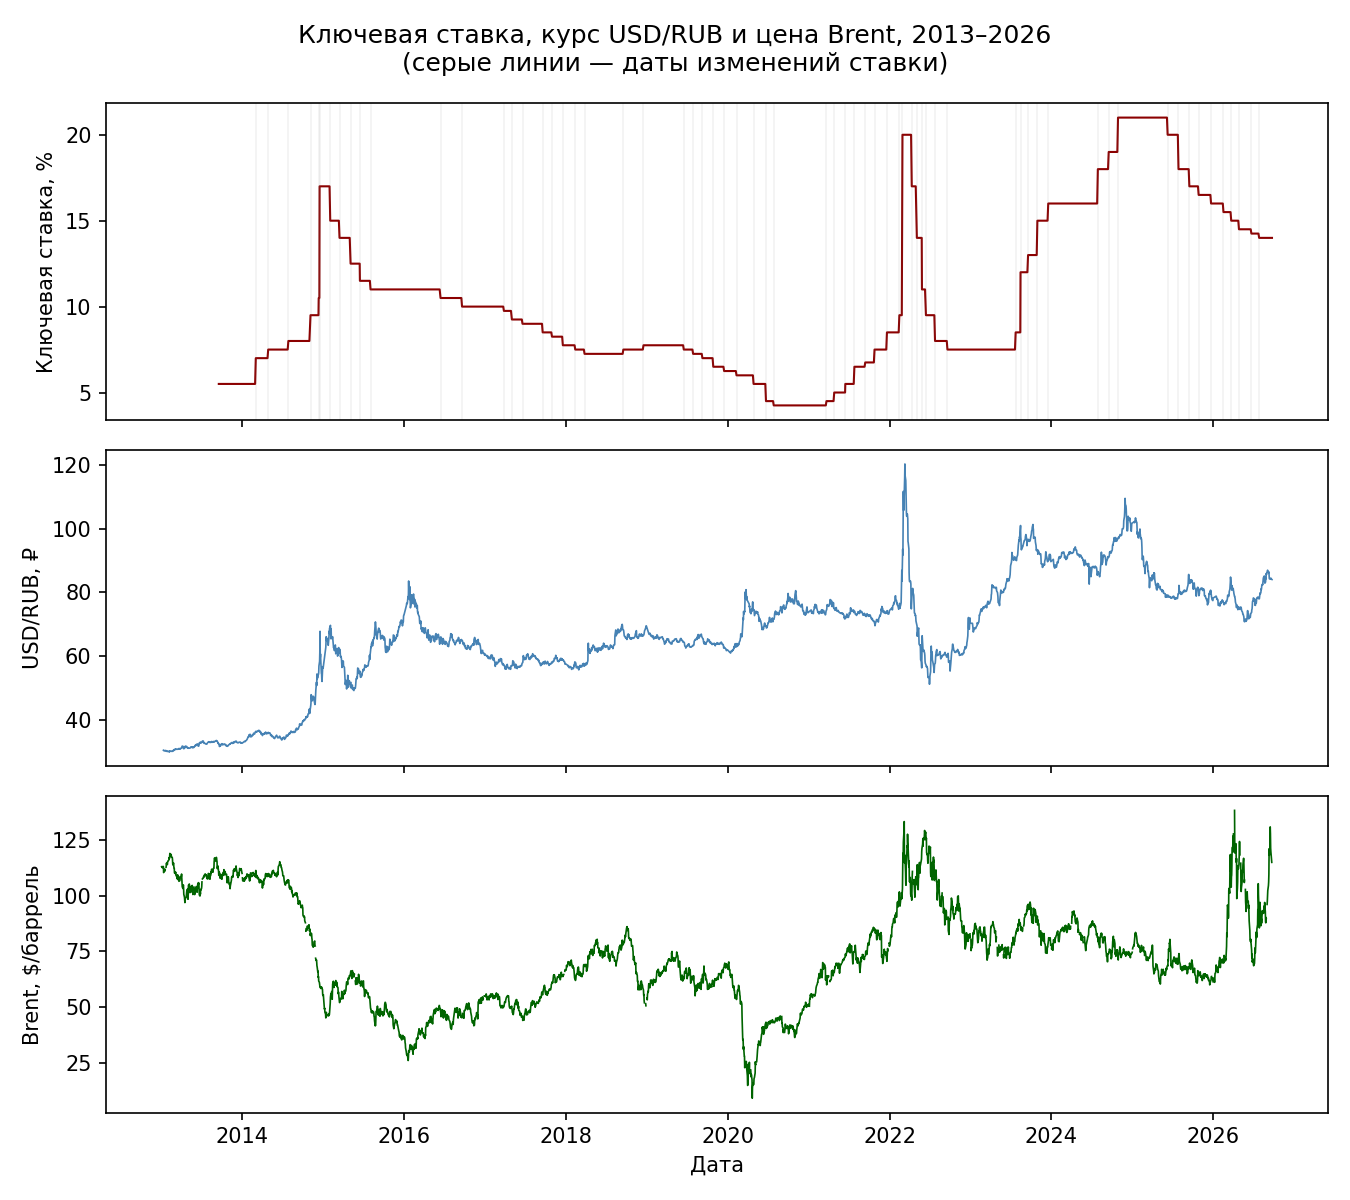

In [3]:
from IPython.display import Image
Image("output/figures/R1_three_series.png")

## Т2. Тесты на стационарность (c и ct)

Тест с трендом (`ct`): для курса тесты без тренда расходились, с трендом — согласны на трендовую стационарность.

In [4]:
pd.read_csv("output/tables/T2_stationarity.csv")

,variable,transform,regression,adf_stat,adf_p,kpss_stat,kpss_p
0,key_rate,level,c,-2.355771,1.546107e-01,0.675690,0.015755
1,key_rate,level,ct,-2.631409,2.656490e-01,0.281465,0.010000
2,key_rate,diff,c,-8.201187,7.223433e-13,0.053728,0.100000
3,key_rate,diff,ct,-8.175851,2.802656e-11,0.057040,0.100000
4,usdrub,level,c,-2.646131,8.383268e-02,1.354168,0.010000
5,usdrub,level,ct,-3.779159,1.764570e-02,0.076322,0.100000
6,usdrub,diff,c,-8.400386,2.239667e-13,0.076761,0.100000
7,usdrub,diff,ct,-8.426128,7.418894e-12,0.038293,0.100000
8,brent,level,c,-2.237052,1.930736e-01,0.302288,0.100000
9,brent,level,ct,-2.666982,2.500459e-01,0.162239,0.036468


## Тест на коинтеграцию и выбор спецификации

Полный протокол решения (чувствительность ранга к лагу) — в `data/processed/var_spec_decision.txt`.

In [5]:
print(Path("data/processed/var_spec_decision.txt").read_text(encoding="utf-8"))

Выбор лага VAR по BIC (данные, не произвольный выбор): p=3
=> k_ar_diff для VECM/Йохансена = 2

Чувствительность ранга коинтеграции к k_ar_diff (обязательная проверка,
т.к. ранг оказался чувствителен к выбору лага):
  k_ar_diff=1 (trace, 5%): ранг=1
    r<=0: stat=32.49, crit_95=29.80 -> отвергаем H0
    r<=1: stat=14.96, crit_95=15.49 -> не отвергаем H0 (граница, разница <1)
    r<=2: stat=5.58, crit_95=3.84 -> отвергаем H0
  k_ar_diff=2 (trace, 5%): ранг=0
    r<=0: stat=22.54, crit_95=29.80 -> не отвергаем H0
    r<=1: stat=11.57, crit_95=15.49 -> не отвергаем H0
    r<=2: stat=4.32, crit_95=3.84 -> отвергаем H0 (граница, разница <1)
  k_ar_diff=3 (trace, 5%): ранг=0
    r<=0: stat=22.66, crit_95=29.80 -> не отвергаем H0
    r<=1: stat=10.64, crit_95=15.49 -> не отвергаем H0
    r<=2: stat=3.47, crit_95=3.84 -> не отвергаем H0 (граница, разница <1)

Основная спецификация использует лаг, выбранный по данным (k_ar_diff=2), а не произвольный: ранг=0 => var_diff.
ВНИМАНИЕ: ранг не одина

## Т3. Выбор лага VAR

In [6]:
pd.read_csv("output/tables/T3_lag_selection.csv")

,criterion,selected_lag
0,aic,3
1,bic,3
2,hqic,3
3,fpe,3


## Т4. Тест Грейнджера (полная выборка)

In [7]:
pd.read_csv("output/tables/T4_granger.csv")

,spec,spec_note,control,causing,caused,f_stat,p_value,conclusion
0,VAR-в-разностях (осн.),основная спецификация,с нефтью в системе,key_rate,usdrub,50.238481,2.209645e-20,отвергаем H0 (есть предсказуемость)
1,VAR-в-разностях (осн.),основная спецификация,с нефтью в системе,usdrub,key_rate,5.384389,4.894227e-03,отвергаем H0 (есть предсказуемость)
2,VAR-в-разностях (осн.),основная спецификация,без нефти,key_rate,usdrub,50.654094,1.156909e-19,отвергаем H0 (есть предсказуемость)
3,VAR-в-разностях (осн.),основная спецификация,без нефти,usdrub,key_rate,5.242508,5.785571e-03,отвергаем H0 (есть предсказуемость)
4,VECM (kd=1),"альтернатива, отвергнутая по данным — см. Т3 и...",с нефтью (в системе),key_rate,usdrub,52.314677,4.516618e-21,отвергаем H0 (есть предсказуемость)
5,VECM (kd=1),"альтернатива, отвергнутая по данным — см. Т3 и...",с нефтью (в системе),usdrub,key_rate,4.924076,7.682670e-03,отвергаем H0 (есть предсказуемость)


## Р2 / Т3c. Импульсный отклик курса на шок ставки (1 п.п., бутстрап-CI)

Отклик на шок ровно 1 п.п. ставки (не 1 стандартное отклонение). Накопленный
эффект и остаточный бутстрап (500 реплик) вместо асимптотического CI.

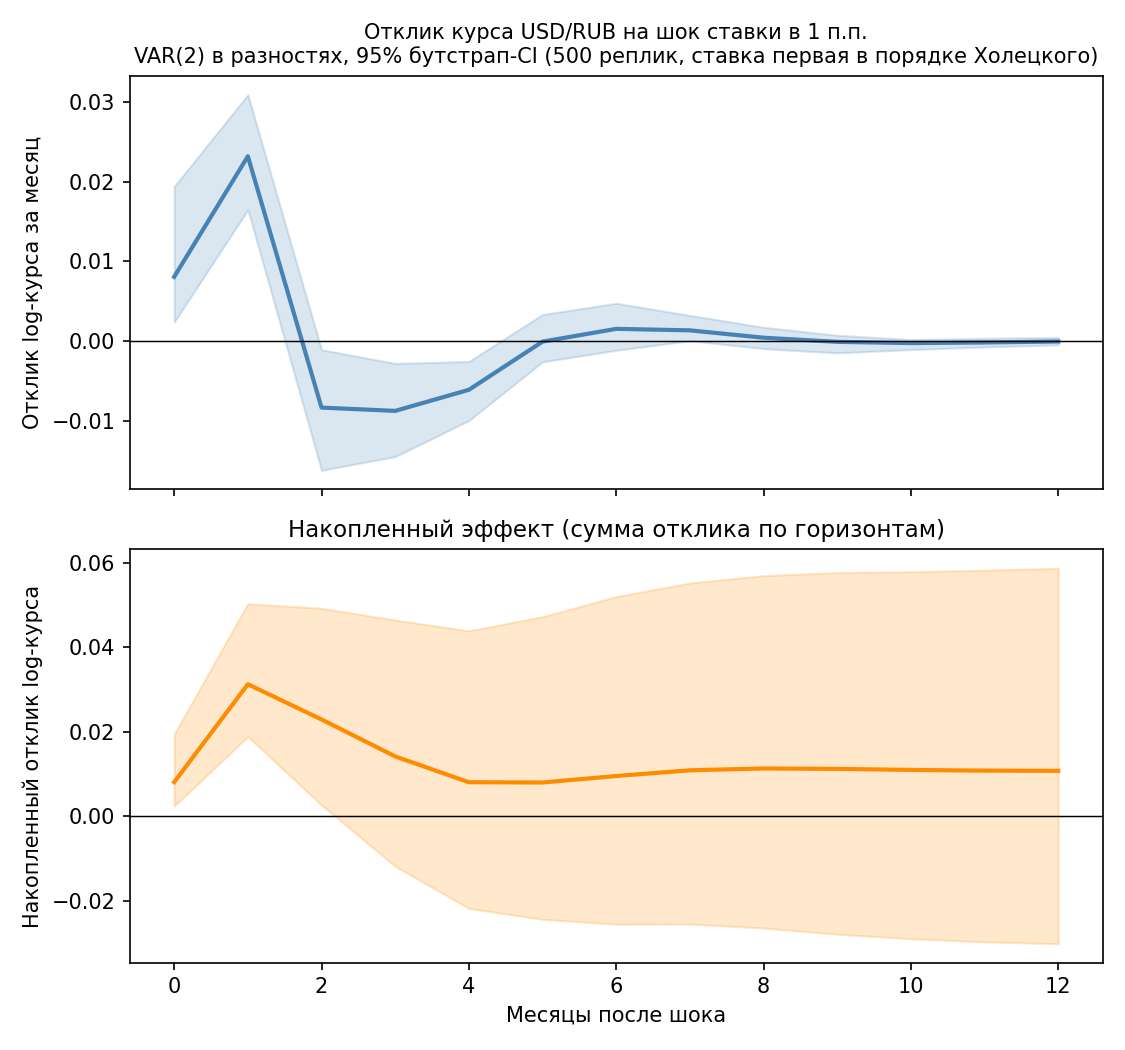

In [8]:
Image("output/figures/R2_irf_rate_to_fx.png")

In [9]:
pd.read_csv("output/tables/T3c_irf_bootstrap.csv")

,horizon,response_per_pp,ci_lo,ci_hi,cum_response_per_pp,cum_ci_lo,cum_ci_hi
0,0,0.008066,0.002383,0.019409,0.008066,0.002383,0.019409
1,1,0.023187,0.016474,0.030911,0.031253,0.018856,0.050320
2,2,-0.008342,-0.016215,-0.001078,0.022911,0.002642,0.049242
3,3,-0.008754,-0.014485,-0.002796,0.014157,-0.011844,0.046446
4,4,-0.006107,-0.009972,-0.002551,0.008050,-0.021816,0.043895
5,5,-0.000064,-0.002604,0.003343,0.007986,-0.024420,0.047238
6,6,0.001539,-0.001155,0.004755,0.009525,-0.025575,0.051992
7,7,0.001350,0.000052,0.003227,0.010875,-0.025522,0.055220
8,8,0.000427,-0.000943,0.001734,0.011302,-0.026465,0.056954
9,9,-0.000090,-0.001478,0.000731,0.011211,-0.027943,0.057685


## Т5 / Т5b. GARCH: выбор спецификации и параметры

Спецификация выбирается сравнением по AIC/BIC (4 кандидата), а не
фиксируется заранее.

In [10]:
pd.read_csv("output/tables/T5b_garch_spec_selection.csv")

,spec,aic,bic,loglik
0,"t, AR(1)-mean, GJR",8201.102310,8243.987937,-4093.551155
1,"t, AR(1)-mean",8226.594271,8263.353380,-4107.297135
2,"t, const-mean",8256.743160,8287.377228,-4123.371580
3,"Normal, const-mean",8543.656214,8568.163469,-4267.828107


In [11]:
pd.read_csv("output/tables/T5_garch.csv")

,period,n_obs,omega,alpha,gamma_asym,beta,persistence,unconditional_var_pct2,ljung_box_resid_p,ljung_box_resid_sq_p
0,весь период,3384,0.032884,0.276164,-0.151392,0.786119,0.986587,2.451767,0.184059,4.522406e-01
1,до 28.02.2022,2252,0.013219,0.160256,-0.119512,0.887065,0.987565,1.063014,0.620967,6.288235e-01
2,после 28.02.2022,1132,0.122707,0.476971,-0.094979,0.570519,1.000000,NaN,0.600657,6.083540e-08


## Р3. Условная волатильность курса (кризисные годы — заливка)

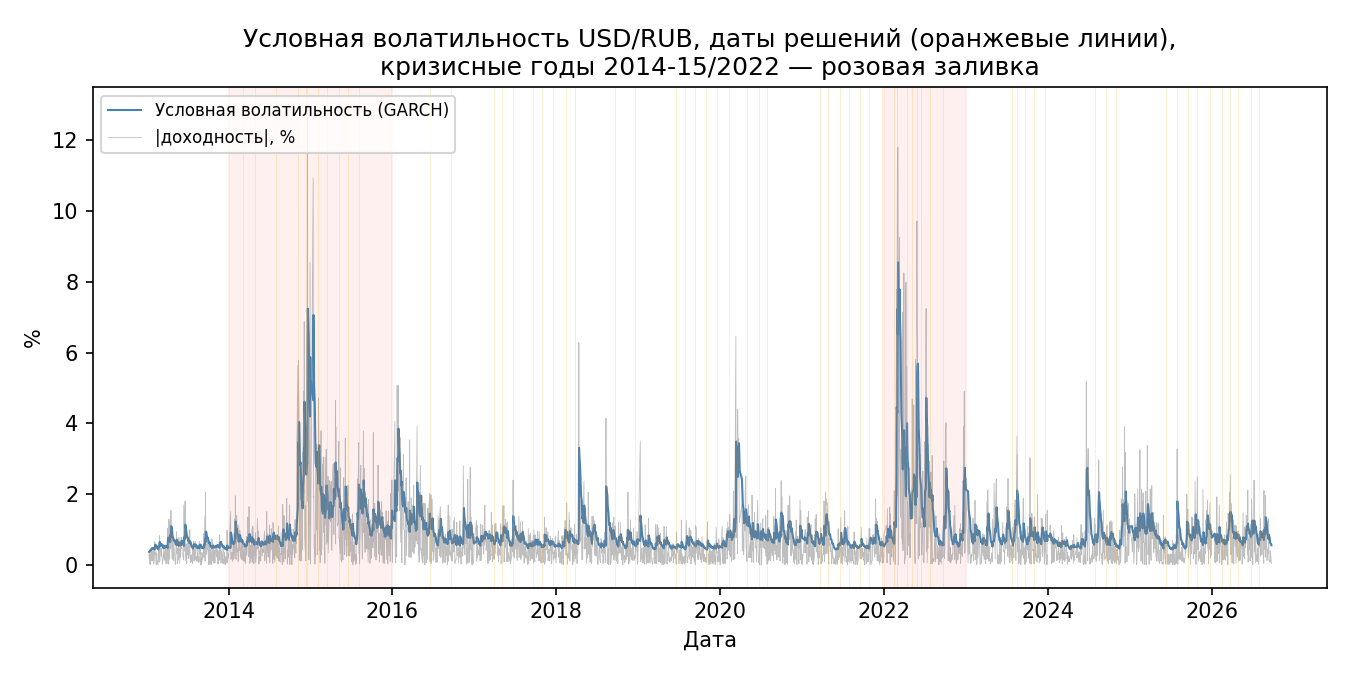

In [12]:
Image("output/figures/R3_conditional_volatility.png")

## Т6a/б/в. Событийное исследование вокруг решений ЦБ

Т6a — наивный тест (плацебо по всей выборке). Т6b — плацебо стратифицировано
по году, аномальная |доходность|: эффект есть на всех событиях (p=0.009),
исчезает без кризисных лет (p=0.457). Т6c — разбивка до/после решения, для
всех событий и отдельно без кризисных лет.

In [13]:
pd.read_csv("output/tables/T6_event_study.csv")

,test,n_events,observed_abs_return_pct,placebo_abs_return_mean,p_value_abs_return,observed_cond_vol,placebo_cond_vol_mean,p_value_cond_vol
0,"наивный (плацебо по всей выборке, без учёта кр...",65,0.920559,0.679863,0.0,1.155711,0.955878,0.006


In [14]:
pd.read_csv("output/tables/T6b_event_study_stratified.csv")

,n_events,n_years,observed_abnormal_abs_return_pct,placebo_abnormal_mean,placebo_abnormal_p95,p_value,subset
0,65,13,0.125223,-0.021054,0.074257,0.009,"все события (плацебо по годам, аномальная |r|)"
1,46,10,0.000090,-0.003445,0.076155,0.457,без 2014/2015/2022 (кризисные годы)


In [15]:
pd.read_csv("output/tables/T6c_before_after.csv")

,pre_decision_abs_return_pct,post_decision_abs_return_pct,baseline_30d_before_window_pct,subset
0,0.838219,1.065814,0.837139,все события
1,0.568322,0.569509,0.568879,без 2014/2015/2022 (кризисные годы)


## Т7 / Р4. Главный результат: нейтрализация кризисных месяцев и скользящее окно

Дамми ставится по одному наблюдению на каждый кризисный месяц (общая дамми
на весь период эффект выброса не гасит — он входит в VAR ещё и как лаг).
Нейтрализация обоих кризисов убирает значимость (p=0.74). Скользящее окно
(Р4) показывает то же самое динамически: доля значимых окон падает с 60%
до 2% при нейтрализации.

In [16]:
pd.read_csv("output/tables/T7_robustness.csv")

,check,variant,n_obs,rate_to_fx_p,fx_to_rate_p,conclusion
0,альтернативный лаг,k_ar_diff=1,156,1.480342e-09,9.975361e-03,оба направления значимы (p<0.05)
1,альтернативный лаг,k_ar_diff=2 (основной),156,2.209645e-20,4.894227e-03,оба направления значимы (p<0.05)
2,альтернативный лаг,k_ar_diff=3,156,1.754738e-17,4.387549e-02,оба направления значимы (p<0.05)
3,подпериод,до 28.02.2022 (вкл. кризис 2014-15),100,6.229590e-02,4.019703e-02,результат смешанный / мало наблюдений
4,подпериод,после 28.02.2022 (вкл. острую фазу 2022),55,7.791928e-01,8.081133e-06,результат смешанный / мало наблюдений
5,подпериод,спокойный период 2015-06..2021-12 (основной),78,5.437274e-01,3.692403e-01,"ни одно направление не значимо (не значит, что..."
6,подпериод,"спокойный период, граница -6мес: 2016-01..2021-12",71,3.155969e-01,5.444677e-01,"ни одно направление не значимо (не значит, что..."
7,подпериод,"спокойный период, граница -6мес: 2015-06..2021-06",72,4.475426e-01,4.839386e-02,результат смешанный / мало наблюдений
8,подпериод,после острой фазы 2022-09..,48,7.446519e-01,3.687210e-01,"ни одно направление не значимо (не значит, что..."
9,нейтрализация кризисных наблюдений (дамми по о...,"2022 (фев-апр), дамми@t",156,1.033315e-01,6.893396e-06,значимость исчезает


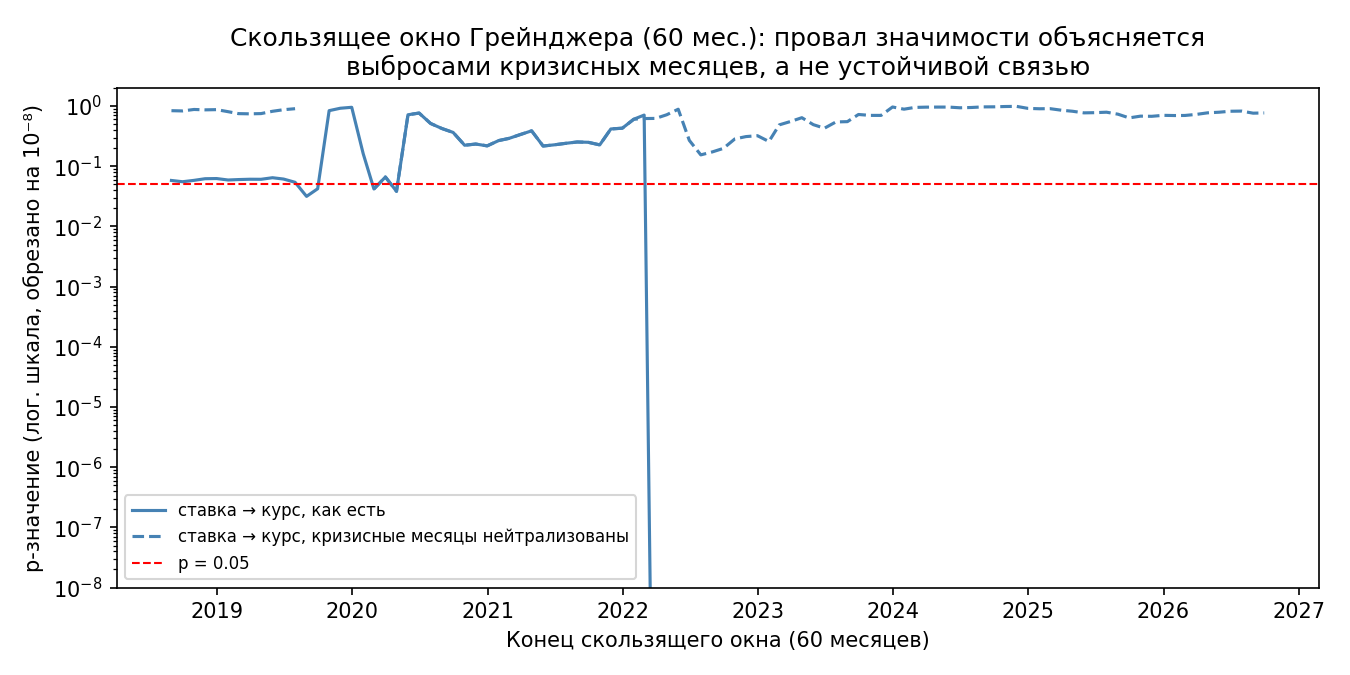

In [17]:
Image("output/figures/R4_rolling_granger.png")

## Т7b. Чувствительность IRF к порядку переменных (на 1 п.п.)

In [18]:
pd.read_csv("output/tables/T7b_irf_ordering.csv")

,ordering,peak_horizon,peak_value_per_pp,sign,cum_effect_h3_per_pp,note
0,"key_rate, usdrub, brent (основной)",1,0.023187,+,0.014157,NaN
1,"usdrub, key_rate, brent",1,0.019540,+,0.001822,нормировка на 1 п.п. верна только для ordering...
2,"brent, key_rate, usdrub",1,0.023113,+,0.014000,нормировка на 1 п.п. верна только для ordering...


## Т7d. Размер эффекта (сумма коэффициентов при лагах ставки в уравнении курса)

In [19]:
pd.read_csv("output/tables/T7d_effect_size.csv")

,effect_sum_L1_L2,ci_lo,ci_hi
0,0.000468,-0.007738,0.008674


## Т8 / Т8b. Прогноз вне выборки и тест Диболда-Мариано

Честно по обоим режимам: в спокойные годы наивный прогноз не хуже VAR; в
кризисные годы VAR со ставкой точнее, но при n=12 разница не значима по
упрощённому DM-тесту.

In [20]:
pd.read_csv("output/tables/T8_outofsample_summary.csv")

,regime,h,n,rmse_naive,mae_naive,rmse_var2_no_rate,mae_var2_no_rate,rmse_var3_with_rate,mae_var3_with_rate
0,"все горизонты, вся выборка",1,117,0.054483,0.032200,0.069478,0.036319,0.053981,0.034080
1,"все горизонты, вся выборка",2,117,0.054662,0.032425,0.059809,0.035581,0.060725,0.037653
2,"все горизонты, вся выборка",3,117,0.054944,0.032759,0.056906,0.035610,0.056733,0.036306
3,цель прогноза — кризисный год (2014/2015/2022),1,12,0.138386,0.091643,0.191423,0.116092,0.127130,0.075586
4,цель прогноза — кризисный год (2014/2015/2022),2,12,0.138386,0.091643,0.151719,0.095427,0.152676,0.108931
5,цель прогноза — кризисный год (2014/2015/2022),3,12,0.138386,0.091643,0.140869,0.092681,0.139695,0.098760
6,цель прогноза — спокойный год,1,105,0.033450,0.025407,0.034512,0.027202,0.037414,0.029337
7,цель прогноза — спокойный год,2,105,0.033776,0.025657,0.036813,0.028742,0.038013,0.029507
8,цель прогноза — спокойный год,3,105,0.034281,0.026029,0.036613,0.029088,0.036827,0.029168


In [21]:
pd.read_csv("output/tables/T8b_diebold_mariano.csv")

,regime,comparison,n,mean_loss_diff,t_stat,p_value,conclusion
0,вся выборка,наивный vs VAR со ставкой,117,0.000054,0.064117,0.948987,разница не значима
1,вся выборка,VAR без ставки vs VAR со ставкой (вложенные — ...,117,0.001913,1.550334,0.123785,разница не значима
2,кризисный год,наивный vs VAR со ставкой,12,0.002989,0.356823,0.727975,разница не значима
3,кризисный год,VAR без ставки vs VAR со ставкой (вложенные — ...,12,0.020481,1.862108,0.089496,разница не значима
4,спокойный год,наивный vs VAR со ставкой,105,-0.000281,-1.450875,0.149824,разница не значима
5,спокойный год,VAR без ставки vs VAR со ставкой (вложенные — ...,105,-0.000209,-2.277452,0.024805,первая модель значимо лучше
